In [63]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve, make_swiss_roll
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import math

In [64]:

from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


In [65]:

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


### 1.1 IMS dataset
This time we will adopt the real dataset. The experiment will used the IMS dataset and also the phm2012 dataset.
First we will consider the IMS dataset, specifically the No.2 dataset No. 3 bearing (channel).


The test rig can be seen below:


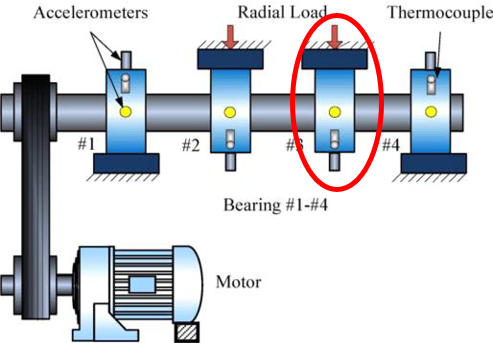



### Training the model using the time-domain data

In [66]:
import scipy.io as scio
from sklearn.model_selection import train_test_split
import pandas as pd
dict_ = scio.loadmat('AE_Diffusion/AE_data_ims/N2_data_C3_.mat')
data_ = dict_['data_c3_']
def normalize(data):
    data_ = (data-np.min(data))/(np.max(data)-np.min(data))
    return data_
#data_h = np.random.randn(1000,4,1024)
data_h = np.random.randn(1000,4,1024)
# data_1 = np.random.randn(4920,4,1024)
data_1 = np.random.randn(4920,4,1024)
ii = 0
for i in range(4920):
  for j in range(4):
    data_1[i,j,:] = normalize(data_[i,1024*j:1024*(j+1)])
    # print(ii)
data_h = data_1[0:1000,:,:]


In [67]:
# data_b = data_1[4000:4920,:,:]
# data_tv = np.concatenate((data_h, data_b),axis = 0)
data_tv = data_h
# data_test  = data_1[1000:-1,:,:]
yh = np.zeros(1000)
# yu = np.ones(920)
# y_ = np.concatenate((yh,yu))
y_ = yh
data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.2, random_state=42)

batch_size = 64 #考虑到样本总数仅为1000个,batch_size设定为64个
# dataset放到dataloader中
dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32).cuda(),torch.tensor(y_1,dtype = torch.float32).cuda())
#dataloader_1 = torch.utils.data.DataLoader(torch.tensor(data_tr,dtype=torch.float32).cuda(), batch_size=batch_size, shuffle=True)
dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True)



#### model construction

In [68]:
from typing import Callable, Dict, List, Optional, Tuple
from typing import Tuple, Iterator

import torch.nn
from torch.nn import Parameter


import torch
import torch.nn as nn
import torch.nn.functional as F


In [69]:
class AttentionLayer(nn.Module):
    def __init__(
        self,
        attention: nn.Module,
        d_model: int,
        n_heads: int,
        d_keys: Optional[int] = None,
        d_values: Optional[int] = None,
    ) -> None:
        super(AttentionLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)
        self.norm = nn.LayerNorm(d_model)
        self.inner_attention = attention
        # Given the paper, I think the Linears should be without biases:
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.sigma_projection = nn.Linear(d_model, n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)

        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads
        x = queries
        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)
        sigma = self.sigma_projection(x).view(B, L, H)

        out, series, prior, sigma = self.inner_attention(
            queries, keys, values, sigma, attn_mask
        )
        out = out.view(B, L, -1)

        return self.out_projection(out), series, prior, sigma


In [70]:
class AnomalyAttention(nn.Module):
    def __init__(
        self,
        win_size: int,
        mask_flag: bool = True,
        scale: Optional[float] = None,
        attention_dropout: float = 0.0,
        output_attention: bool = False,
    ) -> None:
        super(AnomalyAttention, self).__init__()
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)
        self.register_buffer(
            "distances", torch.zeros(1, 1, win_size, win_size), persistent=False
        )
        for i in range(win_size):
            for j in range(win_size):
                self.distances[:, :, i, j] = abs(i - j)

    def forward(self, queries, keys, values, sigma, attn_mask):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1.0 / math.sqrt(E)

        scores = torch.einsum("blhe,bshe->bhls", queries, keys)
        if self.mask_flag:
            if attn_mask is None:
                attn_mask = TriangularCausalMask(B, L, device=queries.device)
            scores.masked_fill_(attn_mask.mask, -np.inf)
        attn = scale * scores
        sigma = sigma.transpose(1, 2)  # B L H ->  B H L
        sigma = torch.sigmoid(sigma * 5) + 1e-5
        sigma = torch.pow(3, sigma) - 1
        window_size = attn.shape[-1]
        sigma = sigma.unsqueeze(-1).repeat(1, 1, 1, window_size)  # B H L L

        prior = self.distances.repeat(sigma.shape[0], sigma.shape[1], 1, 1)
        prior = (
            1.0
            / (math.sqrt(2 * math.pi) * sigma)
            * torch.exp(-(prior**2) / 2 / (sigma**2))
        )
        # Given the paper, I think this should be:
        # prior = (1.0 / (math.sqrt(2 * math.pi) * sigma)) * (
        #     torch.exp(-prior.pow(2) / (2 * sigma.pow(2)))
        # )
        # Moreover, better to to prior rescale here then later in final Transformer Model.
        series = self.dropout(torch.softmax(attn, dim=-1))
        V = torch.einsum("bhls,bshd->blhd", series, values)

        if self.output_attention:
            return (V.contiguous(), series, prior, sigma)
        else:
            return (V.contiguous(), None)



In [71]:
class PositionalEmbedding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super(PositionalEmbedding, self).__init__()
        # Compute the positional encodings once in log space.
        self.register_buffer("pe", torch.zeros(1, max_len, d_model))

        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)
        ).exp()

        self.pe[:, :, 0::2] = torch.sin(position * div_term)
        self.pe[:, :, 1::2] = torch.cos(position * div_term)

    def forward(self, x):
        return self.pe[:, : x.size(1)]

class TokenEmbedding(nn.Module):
    def __init__(self, c_in: int, d_model: int):
        super(TokenEmbedding, self).__init__()
        padding = 1 if torch.__version__ >= "1.5.0" else 2
        self.tokenConv = nn.Conv1d(
            in_channels=c_in,
            out_channels=d_model,
            kernel_size=3,
            padding=padding,
            padding_mode="circular",
            bias=False,
        )
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(
                    m.weight, mode="fan_in", nonlinearity="leaky_relu"
                )

    def forward(self, x):
        x = self.tokenConv(x.permute(0, 2, 1)).transpose(1, 2)
        return x

class DataEmbedding(nn.Module):
    def __init__(self, c_in: int, d_model: int, dropout: float = 0.0):
        super(DataEmbedding, self).__init__()

        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = self.value_embedding(x) + self.position_embedding(x)
        return self.dropout(x)

In [72]:
# from ..common import AnomalyDetector
# from ..layers import AnomalyAttention, AttentionLayer, DataEmbedding
# from ...models import BaseModel
# from ...optim.loss import Loss
# from ...optim.trainer import Trainer
# from ...utils.torch_utils import tensor2scalar


class BaseModel(torch.nn.Module):
    def grouped_parameters(self) -> Tuple[Iterator[Parameter], ...]:
        return self.parameters(),


class EncoderLayer(nn.Module):
    def __init__(
        self,
        attention: nn.Module,
        d_model: int,
        d_ff: Optional[int] = None,
        dropout: float = 0.1,
        activation: str = "relu",
    ) -> None:
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x: torch.Tensor, attn_mask=None):
        new_x, attn, mask, sigma = self.attention(x, x, x, attn_mask=attn_mask)
        x = x + self.dropout(new_x)
        y = x = self.norm1(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))

        return self.norm2(x + y), attn, mask, sigma


class Encoder(nn.Module):
    def __init__(
        self, attn_layers: List[nn.Module], norm_layer: Optional[nn.Module] = None
    ):
        super(Encoder, self).__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.norm = norm_layer

    def forward(self, x: torch.Tensor, attn_mask=None):
        # in shape: [bz, win, d_model]
        series_list = []
        prior_list = []
        sigma_list = []
        for attn_layer in self.attn_layers:
            x, series, prior, sigma = attn_layer(x, attn_mask=attn_mask)
            series_list.append(series)
            prior_list.append(prior)
            sigma_list.append(sigma)

        if self.norm is not None:
            x = self.norm(x)

        return x, series_list, prior_list, sigma_list


class AnomalyTransformer(BaseModel):
    def __init__(
        self,
        win_size: int,
        input_dim: int,
        d_model: int = 512,
        n_heads: int = 8,
        e_layers: int = 3,
        d_ff: int = 512,
        dropout: float = 0.0,
        activation: str = "gelu",
        output_attention: bool = True,
    ) -> None:
        super(AnomalyTransformer, self).__init__()
        self.output_attention = output_attention

        # Encoding
        self.embedding = DataEmbedding(input_dim, d_model, dropout)

        # Encoder
        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(
                        AnomalyAttention(
                            win_size,
                            False,
                            attention_dropout=dropout,
                            output_attention=output_attention,
                        ),
                        d_model,
                        n_heads,
                    ),
                    d_model,
                    d_ff,
                    dropout=dropout,
                    activation=activation,
                )
                for _ in range(e_layers)
            ],
            norm_layer=nn.LayerNorm(d_model),
        )

        self.projection = nn.Linear(d_model, input_dim, bias=True)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, ...]:
        # x in shape [bz, win, feats]
        enc_out = self.embedding(x)  # out shape: [bz, win, d_model]
        enc_out, series, prior, sigmas = self.encoder(enc_out)

        enc_out = self.projection(enc_out)

        if self.output_attention:
            return enc_out, series, prior, sigmas
        else:
            return (enc_out,)  # out shape [batch_size, seq_len, num_features]



#### Trying to train the model

In [73]:
import abc
import math
from typing import Tuple, Union


import torch
from torch.nn import functional as F


class Loss(torch.nn.modules.loss._Loss, abc.ABC):
    def __init__(self, size_average=None, reduce=None, reduction: str = 'mean'):
        super(Loss, self).__init__(size_average, reduce, reduction)

    @abc.abstractmethod
    def forward(self, predictions: Tuple[torch.Tensor, ...],
                targets: Tuple[torch.Tensor, ...], *args, **kwargs) -> Union[torch.Tensor, Tuple[torch.Tensor]]:
        raise NotImplementedError()


In [74]:
import gc
import math
import os
from typing import List, Tuple, Union, Optional

import numpy as np
import pandas as pd
import torch
from torch.nn.utils.rnn import pack_sequence
from torch.optim import Optimizer
# from torch.optim.lr_scheduler import StepL

activations = {
    'relu': torch.nn.ReLU(),
    'sigmoid': torch.nn.Sigmoid(),
    'tanh': torch.nn.Tanh(),
    'linear': torch.nn.Identity()
}


def tensor2scalar(tensor: torch.Tensor) -> Union[torch.Tensor, float, int]:
    if tensor.numel() == 1:
        return tensor.item()

    return tensor



In [75]:
import collections.abc
import functools
import importlib
import inspect
import itertools
import numpy as np
from typing import List, TypeVar, Tuple, Union, Dict, Any, Iterator, Optional

T = TypeVar('T')

def pack_tuple(x: Union[T, Tuple[T, ...]]) -> Tuple[T, ...]:
    if isinstance(x, tuple):
        return x

    return x,

In [76]:
import functools
import itertools
import logging
import os
import time
from collections import defaultdict
from typing import Callable, Dict, Any, Union, Tuple, List, Optional

import torch
import tqdm



SUPPORTED_HOOKS = ['post_validation']


class default_log_fn:
    def __init__(self):
        self.history = defaultdict(list)

    def __call__(self, metric_name: str, metric_value: Any):
        self.history[metric_name].append(metric_value)


class Trainer:
    def __init__(self, train_iter: torch.utils.data.DataLoader, val_iter: torch.utils.data.DataLoader,
                 optimizer: Callable = torch.optim.Adam,
                 scheduler: Callable = torch.optim.lr_scheduler.MultiStepLR,
                 device: Union[str, torch.device] = 'cpu', checkpoints: bool = False, out_dir: Optional[str] = None,
                 batch_dimension: int = 0):

        self.opt = optimizer
        self.sched = scheduler
        self.train_iter = train_iter
        self.val_iter = val_iter
        self.device = device
        self.batch_dimension = batch_dimension

        # Hooks
        self.hooks = defaultdict(list)

        # Legacy interface for backward compatibility
        if checkpoints:
            self.add_hook(CheckpointHook(out_dir), 'post_validation')

    def validate_batch(self, network: torch.nn.Module, val_metrics: Dict[str, Callable],
                       b_inputs: Tuple[torch.Tensor, ...], b_targets: Tuple[torch.Tensor, ...], *args, **kwargs) \
            -> Dict[str, float]:
        res = pack_tuple(network(b_inputs))

        batch_metrics = {}
        for m_name, m in val_metrics.items():
            batch_metrics[m_name] = tensor2scalar(m(res, b_targets, b_inputs, *args, **kwargs).detach().cpu()) \
                                       * b_inputs[0].shape[self.batch_dimension]

        return batch_metrics

    def validate_model_once(self, network: torch.nn.Module, val_metrics: Dict[str, Callable], *args,
                            print_progress: bool = False, **kwargs) -> Dict[str, Any]:
        network.eval()
        total = 0
        current_metrics = {k: 0 for k in val_metrics.keys()}
        if print_progress:
            val_iter = tqdm.tqdm(self.val_iter, desc=f'Loss: {0:.3f}')
        else:
            val_iter = self.val_iter

        with torch.no_grad():
            for b_inputs, b_targets in val_iter:
                b_inputs = tuple(b_inp.to(self.device) for b_inp in b_inputs)
                b_targets = tuple(b_tar.to(self.device) for b_tar in b_targets)

                total += b_inputs[0].shape[self.batch_dimension]
                batch_metrics = self.validate_batch(network, val_metrics, b_inputs, b_targets, *args, **kwargs)
                current_metrics = {k: v_c + v_b for (k, v_c), (k, v_b)
                                   in zip(current_metrics.items(), batch_metrics.items())}

                if print_progress:
                    val_iter.set_description(
                        ', '.join(f'{m_name}: {m_value / total:.3f}' for m_name, m_value in current_metrics.items())
                    )

        for m_name in val_metrics:
            current_metrics[m_name] /= max(total, 1)

        return current_metrics

    def train_batch(self, network: torch.nn.Module, losses: List[Loss], optimizers: List[torch.optim.Optimizer],
                    epoch: int, num_epochs: int, b_inputs: Tuple[torch.Tensor, ...],
                    b_targets: Tuple[torch.Tensor, ...]) -> List[float]:
        batch_loss = [0 for _ in optimizers]
        for i, (optimizer, loss) in enumerate(zip(optimizers, losses)):
            res = pack_tuple(network(b_inputs))
            l = loss(res, b_targets, epoch=epoch, num_epochs=num_epochs)
            optimizer.zero_grad(True)
            opt_params = list(itertools.chain(*(group['params'] for group in optimizer.param_groups)))
            l.backward(inputs=opt_params)
            optimizer.step()
            optimizer.zero_grad(True)
            batch_loss[i] = tensor2scalar(l.detach().cpu()) * b_inputs[0].shape[self.batch_dimension]

        return batch_loss

    def train_epoch(self, network: torch.nn.Module, losses: List[Loss], optimizers: List[torch.optim.Optimizer],
                    schedulers: List[torch.optim.lr_scheduler._LRScheduler], epoch: int, num_epochs: int,
                    val_metrics: Dict[str, Callable], log_fn: Callable[[str, Any], None] = default_log_fn) -> bool:
        print('Training:', flush=True)
        network.train()
        train_iter = tqdm.tqdm(self.train_iter, desc=f'Loss: {0:.3f}')
        total, avg_loss = 0, [0 for _ in optimizers]
        start = time.perf_counter()
        for b_inputs, b_targets in train_iter:
            b_inputs = tuple(b_inp.to(self.device) for b_inp in b_inputs)
            b_targets = tuple(b_tar.to(self.device) for b_tar in b_targets)

            batch_loss = self.train_batch(network, losses, optimizers, epoch, num_epochs, b_inputs, b_targets)
            avg_loss = [a + b for a, b in zip(avg_loss, batch_loss)]

            total += b_inputs[0].shape[self.batch_dimension]
            train_iter.set_description(', '.join(f'Loss {i:d}: {loss / total:.3f}' for i, loss in enumerate(avg_loss)))

        end = time.perf_counter()
        log_fn('train_time', end - start)

        for i, l in enumerate(avg_loss):
            log_fn(f'train_loss_{i}', l / total)

        for scheduler in schedulers:
            scheduler.step()

        print('Validation:', flush=True)
        start = time.perf_counter()
        current_metrics = self.validate_model_once(network, val_metrics, print_progress=True, epoch=epoch,
                                                   num_epochs=num_epochs)
        end = time.perf_counter()
        log_fn('val_time', end - start)

        for m_name, m_value in current_metrics.items():
            log_fn(f'val_{m_name}', m_value)

        # Run post-validation hooks
        if not all(hook(self, network, optimizers, epoch, current_metrics) for hook in self.hooks['post_validation']):
            # Stop Training due to negative hook feedback
            return False

        return True

    def train(self, network: torch.nn.Module, losses: Union[List[Loss], Loss], num_epochs: int, val_metrics: Dict[str, Callable] = None,
              start_epoch: int = 0, log_fn: Callable[[str, Any], None] = default_log_fn):
        # We expect this to return a tuple of size k, where k is the number of parameter groups.
        # Each group gets its own optimizer and the loss function is expected to return the
        # same number of individual losses
        network = network.to(self.device)
        parameters = pack_tuple(network.grouped_parameters())
        if isinstance(losses, Loss):
            losses = [losses] * len(parameters)
        else:
            assert len(losses) == len(parameters)
        losses = [loss.to(self.device) for loss in losses]

        if val_metrics is None:
            val_metrics = {f'loss_{i}': loss for i, loss in enumerate(losses)}

        optimizers = [self.opt(params) for params in parameters]
        schedulers = [self.sched(optimizer) for optimizer in optimizers]

        for e in range(start_epoch, start_epoch + num_epochs):
            logging.info(f'Epoch {e + 1:d} of {start_epoch + num_epochs:d}:')
            if not self.train_epoch(network, losses, optimizers, schedulers, e, num_epochs, val_metrics, log_fn):
                break

    def add_hook(self, hook: Callable, type: str = 'post_validation'):
        if type not in SUPPORTED_HOOKS:
            raise ValueError(f'Hook type "{type}" is not supported!')

        self.hooks[type].append(hook)


def open_file_in_dir(name, out_dir, mode='w+b'):
    if not os.path.isdir(out_dir):
        os.makedirs(out_dir)

    return open(os.path.join(out_dir, name), mode=mode)


class CheckpointHook:
    def __init__(self, out_dir: Optional[str] = None, checkpoint_interval: int = 10,
                 file_write_fn: Optional[Callable] = None, file_read_fn: Optional[Callable] = None):
        self.checkpoint_interval = checkpoint_interval

        if file_write_fn is None:
            if out_dir is None:
                raise ValueError('Either file_write_fn or out_dir must be specified!')
            file_write_fn = functools.partial(open_file_in_dir, out_dir=out_dir)
        self.file_write_fn = file_write_fn

        if file_read_fn is None:
            if out_dir is None:
                raise ValueError('Either file_read_fn or out_dir must be specified!')
            file_read_fn = functools.partial(open_file_in_dir, out_dir=out_dir)
        self.file_read_fn = file_read_fn

    def save_model(self, filename: str, network: torch.nn.Module, optimizers: List[torch.optim.Optimizer]):
        with self.file_write_fn(filename, mode='wb') as f:
            torch.save(dict(model=network.state_dict(), opt=[opt.state_dict() for opt in optimizers]), f)

    def load_model_state(self, filename: str,) -> Dict:
        with self.file_read_fn(filename, mode='rb') as f:
            state = torch.load(f)

        return state

    def __call__(self, trainer: Trainer, network: torch.nn.Module, optimizers: List[torch.optim.Optimizer],
                 epoch: int, val_metrics: Dict[str, float]) -> bool:
        if (epoch + 1) % self.checkpoint_interval != 0:
            return True

        self.save_model(f'snap_{epoch + 1:03d}.pth', network, optimizers)

        return True


class EarlyStoppingHook:
    def __init__(self, metric: str = 'loss_0', invert_metric: bool = True, patience: int = 10, epsilon: float = 0):
        self.metric = metric
        self.invert_metric = invert_metric
        self.patience = patience
        self.epsilon = epsilon

        self.__best_metric = -float('inf')
        self.best_epoch = 0
        self.decrease_counter = 0

    @property
    def best_metric(self) -> float:
        return -self.__best_metric if self.invert_metric else self.__best_metric

    def save_best_model(self, trainer: Trainer, network: torch.nn.Module, optimizers: List[torch.optim.Optimizer]):
        for hook in trainer.hooks['post_validation']:
            if isinstance(hook, CheckpointHook):
                hook.save_model('best_model.pth', network, optimizers)
                return

    def load_best_model(self, trainer: Trainer, network: torch.nn.Module, total_epochs: int):
        if total_epochs > 0 and self.best_epoch != total_epochs - 1:
            for hook in trainer.hooks['post_validation']:
                if isinstance(hook, CheckpointHook):
                    # Load model state from best epoch
                    state = hook.load_model_state('best_model.pth')
                    network.load_state_dict(state['model'])
                    del state
                    break

        return network

    def __call__(self, trainer: Trainer, network: torch.nn.Module, optimizers: List[torch.optim.Optimizer],
                 epoch: int, val_metrics: Dict[str, float]) -> bool:
        score = -val_metrics[self.metric] if self.invert_metric else val_metrics[self.metric]

        if score > self.__best_metric + self.epsilon:
            self.__best_metric = score
            self.best_epoch = epoch
            self.decrease_counter = 0
            self.save_best_model(trainer, network, optimizers)
        else:
            self.decrease_counter += 1
            if self.decrease_counter >= self.patience:
                return False

        return True

    def get_best_epoch(self, _print: bool = False) -> int:
        if _print:
            logging.info(f'Best Epoch was {self.best_epoch + 1:d} with {self.best_metric:.3f} average {self.metric}.')
        return self.best_epoch

In [77]:
def symm_kl_loss(p, q, eps=1e-4, reduce=True):
    res1 = torch.sum(p * (torch.log(p + eps) - torch.log(q + eps)), dim=-1)
    res2 = torch.sum(q * (torch.log(q + eps) - torch.log(p + eps)), dim=-1)
    if reduce:
        return res1.mean() + res2.mean()
    else:
        return res1.mean(dim=1) + res2.mean(dim=1)

class AnomTransf_Loss(Loss):
    def __init__(self, lamb: float = 3.0):
        super(AnomTransf_Loss, self).__init__()

        self.lamb = lamb
        self.mse_loss = nn.MSELoss()

    def calc_association_disc(
        self, series: List[torch.Tensor], priors: List[torch.Tensor]
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        series_loss = 0.0
        prior_loss = 0.0
        for serie, prior in zip(series, priors):
            prior_rescale = prior.div(torch.sum(prior, dim=-1, keepdim=True))
            # Calc series loss
            series_loss += symm_kl_loss(serie, prior_rescale.detach())
            # Calc prior loss
            prior_loss += symm_kl_loss(prior_rescale, serie.detach())

        series_loss = series_loss / len(priors)
        prior_loss = prior_loss / len(priors)

        return series_loss, prior_loss

    def forward(
        self,
        predictions: Tuple[torch.Tensor, ...],
        targets: Tuple[torch.Tensor, ...] = None,
        *args,
        **kwargs,
    ) -> torch.Tensor:

        output, series, prior, _ = predictions
        (input,) = targets

        # Calc losses
        series_loss, prior_loss = self.calc_association_disc(series, prior)
        recon_loss = self.mse_loss(output, input)

        loss1 = recon_loss - self.lamb * series_loss
        loss2 = recon_loss + self.lamb * prior_loss

        return loss1, loss2, recon_loss


class AnomTransf_Trainer(Trainer):
    def __init__(
        self,
        *args,
        **kwargs,
    ):
        super(AnomTransf_Trainer, self).__init__(*args, **kwargs)

    def validate_batch(self, network: torch.nn.Module, val_metrics: Dict[str, Callable],
                       b_inputs: Tuple[torch.Tensor, ...], b_targets: Tuple[torch.Tensor, ...], *args, **kwargs) \
            -> Dict[str, float]:
        (x,) = b_inputs

        batch_metrics = {}
        for m_name, m in val_metrics.items():
            _, loss2, recon_loss = m(network(x), b_targets, *args, **kwargs)
            batch_metrics['loss_0'] = tensor2scalar(recon_loss.detach().cpu()) * b_inputs[0].shape[self.batch_dimension]
            batch_metrics['loss_1'] = tensor2scalar((loss2-recon_loss).detach().cpu()) * b_inputs[0].shape[self.batch_dimension]

        return batch_metrics

    def train_batch(
        self,
        network: AnomalyTransformer,
        losses: List[Loss],
        optimizers: List[torch.optim.Optimizer],
        epoch: int,
        num_epochs: int,
        b_inputs: Tuple[torch.Tensor, ...],
        b_targets: Tuple[torch.Tensor, ...],
    ) -> List[float]:
        (x,) = b_inputs

        opt, *_ = optimizers
        loss, *_ = losses

        # Forward pass
        loss1, loss2, recon_loss = loss(network(x), b_targets)

        # Backward pass - Minimax strategy
        opt.zero_grad(True)
        loss1.backward(retain_graph=True)
        loss2.backward()
        opt.step()

        return [loss1.item(), loss2.item(), recon_loss.item()]


In [78]:
model_t = AnomalyTransformer(win_size = 4, input_dim = 1024).cuda()
# dd = torch.randn((64,4,1024))
# out_dd1,out_dd2,out_dd3,out_dd4 = model_t(dd)

In [79]:
Trainer_ims_AT = AnomTransf_Trainer(train_iter = 10000, val_iter = 10000)

In [80]:
num_epoch = 1000

dataloader = dataloader_1


# epoch遍历
for t in range(num_epoch):
    # dataloader遍历
    model_t.train()
    for idx, (batch_x, batch_y) in enumerate(dataloader):
        loss_1,loss_2,loss_recon_ = Trainer_ims_AT.train_batch(model_t,(AnomTransf_Loss(lamb=3.0),),(torch.optim.Adam(model_t.parameters(),lr = 0.0001),),1000,1000,(batch_x,),(batch_x,))
        print(
            "[Epoch %d/%d]   [loss_1 %f] [loss_2: %f] [loss_recon_: %f]"
                % (t,num_epoch, loss_1, loss_2, loss_recon_)
        )




流式输出内容被截断，只能显示最后 5000 行内容。
[Epoch 434/1000]   [loss_1 -19.445810] [loss_2: 19.484327] [loss_recon_: 0.019258]
[Epoch 434/1000]   [loss_1 -20.595343] [loss_2: 20.638025] [loss_recon_: 0.021341]
[Epoch 434/1000]   [loss_1 -20.383823] [loss_2: 20.420361] [loss_recon_: 0.018268]
[Epoch 434/1000]   [loss_1 -20.441338] [loss_2: 20.477375] [loss_recon_: 0.018018]
[Epoch 434/1000]   [loss_1 -20.279255] [loss_2: 20.316883] [loss_recon_: 0.018814]
[Epoch 434/1000]   [loss_1 -20.025345] [loss_2: 20.062523] [loss_recon_: 0.018589]
[Epoch 434/1000]   [loss_1 -19.547853] [loss_2: 19.586164] [loss_recon_: 0.019156]
[Epoch 434/1000]   [loss_1 -19.922108] [loss_2: 19.956497] [loss_recon_: 0.017195]
[Epoch 434/1000]   [loss_1 -19.943121] [loss_2: 19.990751] [loss_recon_: 0.023816]
[Epoch 435/1000]   [loss_1 -20.550093] [loss_2: 20.587038] [loss_recon_: 0.018473]
[Epoch 435/1000]   [loss_1 -20.734587] [loss_2: 20.774160] [loss_recon_: 0.019786]
[Epoch 435/1000]   [loss_1 -20.660324] [loss_2: 20.695999] [

KeyboardInterrupt: 

#### anomaly detector

In [81]:
def compute_online_anomaly_score(
    model, inputs: Tuple[torch.Tensor, ...]
) -> torch.Tensor:
    # Input of shape [B, T, F] output of shape (B,)
    (x,) = inputs

    # Temperatur from online implementation
    temperature = 50.
    model.eval()
    with torch.no_grad():
        output, series, priors, _ = model(x)
        # Calc recon loss with mean over features: out shape [B, T]
        recon_loss = F.mse_loss(x, output, reduction='none').mean(dim=-1)

        # Init losses
        series_loss = 0.0
        prior_loss = 0.0
        for serie, prior in zip(series,priors):
            prior_norm = prior.div(torch.sum(prior, dim=-1, keepdim=True))
            series_loss += symm_kl_loss(serie, prior_norm, reduce=False) * temperature

        metric = torch.softmax((-series_loss - prior_loss), dim=-1)
        anomaly_scores = metric * recon_loss

    # Return last observations
    return anomaly_scores[:,-1]
data_tv = torch.tensor(data_1,dtype = torch.float32).cuda()
anomaly_score_ = compute_online_anomaly_score(model_t, (data_tv,))



In [82]:
HI_m_ = anomaly_score_.cpu().numpy()
HI_m = np.ones(984)
for i in range(984):
  HI_m[i] = np.mean(HI_m_[5*i:5*(i+1)])


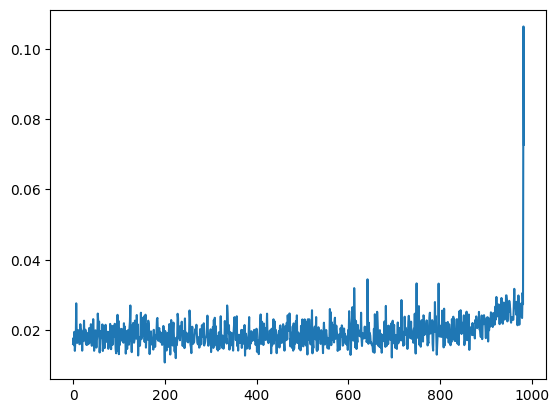

In [83]:
plt.plot(HI_m)

In [84]:
import scipy.io as scio
HI_t = HI_m
HI_t_ = HI_m_
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_anomaly_transformer(3).mat',{'HI_t':HI_t,'HI_t_':HI_t_})

In [ ]:
def compute_online_anomaly_score(
    self, inputs: Tuple[torch.Tensor, ...]
) -> torch.Tensor:
    # Input of shape [B, T, F] output of shape (B,)
    (x,) = inputs

    # Temperatur from online implementation
    temperature = 50.

    with torch.no_grad():
        output, series, priors, _ = self.model(x)
        # Calc recon loss with mean over features: out shape [B, T]
        recon_loss = F.mse_loss(x, output, reduction='none').mean(dim=-1)

        # Init losses
        series_loss = 0.0
        prior_loss = 0.0
        for serie, prior in zip(series,priors):
            prior_norm = prior.div(torch.sum(prior, dim=-1, keepdim=True))
            series_loss += symm_kl_loss(serie, prior_norm, reduce=False) * temperature

        metric = torch.softmax((-series_loss - prior_loss), dim=-1)
        anomaly_scores = metric * recon_loss

    # Return last observations
    return anomaly_scores[:,-1]

In [ ]:

wdt_discriminator=WDT_discriminator().cuda()
wdt_generator=WDT_generator().cuda()
optimizer_g = torch.optim.Adam(wdt_generator.parameters(),lr=5e-5)
optimizer_d = torch.optim.Adam(wdt_discriminator.parameters(),lr=5e-5)

In [ ]:
#针对Pytorch的数据归一化
def normalize_t(data):
    return (data-torch.min(data))/(torch.max(data)-torch.min(data))
data_test= data_vali.view(-1,1,4096)
num_test = 4920
wdt_discriminator.eval()
HI_m_ = wdt_discriminator(data_test)

In [ ]:
import matplotlib.pyplot as plt

HI_m = HI_m_.detach().cpu().numpy().reshape(-1)
plt.plot(HI_m)

In [ ]:
#针对numpy数组的标准化
def normalize_np(data):
    return (data-np.min(data))/(np.max(data)-np.min(data))
HI_t_ = np.ones(984)
HI_t = np.ones(984)
for i in range(984):
  HI_t_[i] = np.mean(HI_m[5*i:(i+1)*5])

HI_t = normalize_np(HI_t_)
plt.plot(HI_t)

In [ ]:
import scipy.io as scio
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_WGAN-GP.mat',{'HI_t':HI_t,'HI_t_':HI_t_})